This code was written for running neuron population morphology-based clustering 

Let's start by importing some general necessary packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

# Dataset access 
First we need to set up the CAVE client and default dataset, as well as SeaTable access and import of info table

In [2]:
from fafbseg import flywire

flywire.set_default_dataset('wclee_aedes_brain')

Default dataset set to "wclee_aedes_brain".


Let's load the aedes table and access to the segmentation


In [4]:
import os # might be necessary for calling token stored in env variable
import seaserpent as ss 

aedes = ss.Table(table='aedes_main', server='https://flytable.mrc-lmb.cam.ac.uk/', auth_token=os.environ['SEATABLE_TOKEN']) # environment variable has to be defined before with access token 
ades = aedes.to_frame()
aedes.head()

,supervoxel_id,root_id,serial_id,point_xyz,side,subsubclass,type,group,superclass,axon_tract,...,root_duplicated,soma_xyz,birthtime,nerve,synonyms,flywire_type,instance,receptor,lrcid,serial_id_saved
row_id,,,,,,,,,,,,,,,,,,,,,
d76kgJ7aRSSG8FVDNH4ZWQ,76280889268882312,648518347481404235,13765,"33214,12071,4600",R,<NA>,<NA>,11758,central,None,...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13765
U31NnNtIRySAo2U_QvFpmQ,75226526269985001,648518347509965429,10001,"25416.783203125,20689.4375,4378.982421875",R,RG1,G1a_ivPN,10001,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,VP3+VP1l_ivPN,<NA>,<NA>,C003:193,10001
PpXg8uYIQRSh2gGzA5R3cA,75226526269992020,648518347501126977,10002,"25449.474609375,20758.744140625,4378.982421875",R,RG1,G1b_ilPN,10002,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:195,10002
LKO0_NSdQiSLPO25G2RTcw,75648601497466950,648518347488545557,10003,"28597.75,19607.583984375,4773.5",L,RG1,G1_PN,10001,central,[mALT],...,False,<NA>,<NA>,<NA>,Marin 2020: VP3+VP1l ivPN,<NA>,<NA>,<NA>,<NA>,10003
ElYAergFQuya_RnzVWCo3w,75367126520739993,648518347570434664,10004,"26120.669921875,19894.88671875,4773.5",R,G2,G2_lPN,10004,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:244,10004


# Data selection 

At this point we need to slice our data table to only contain the neurons we want to cluster. The following cells show an example for neurons of the class 'ALPN', as well as some duplicate filtering. 

Start by filtering neurons of a certain class and ensuring that 'status' is not a dupliccate, fragment or tiny

In [5]:
alpn_index = ~aedes['status'].isin(['duplicate', 'fragment', 'tiny']) and aedes['class'] == 'ALPN' #create a mask for filtering alpns
alpn = aedes[alpn_index]
print("There are " + str(len(alpn)) + " alpns")

There are 606 alpns


Next, we check for root_id duplicates, in case they weren't annotated as such; and drop one of the copies 

In [6]:
#check for root_id duplicates
root_id_dups = len(alpn.root_id) - len(np.unique(alpn.root_id))
#drop duplicates
alpn.drop_duplicates(subset='root_id', keep='last', inplace=True)
print("Dropped " + str(root_id_dups) + " root_id duplicates")
print("There are now " + str(len(alpn)) + " alpns")

Dropped 32 root_id duplicates
There are now 574 alpns


Now we can go ahead and load the neurons. For clustering we need the dotprops of the neurons, so we'll use the 'flywire.get_l2_dotprops()' function to load them and then scale them to $\mu m$ units

In [7]:
segment_ids = alpn.root_id.to_list()
dps = flywire.get_l2_dotprops(segment_ids)
dps_um = dps * (1/1000)

Fetching L2 IDs:   0%|          | 0/574 [00:00<?, ?it/s]

Fetching L2 vectors:   0%|          | 0/347245 [00:00<?, ?it/s]

Creating dotprops:   0%|          | 0/574 [00:00<?, ?it/s]

Multiplying:   0%|          | 0/574 [00:00<?, ?it/s]

# Clustering

Next, we will write some code to run the all by all nblast similarity score, followed by the hierarchical clustering of the neurons

In [9]:
import navis as nv
aba = nv.nblast_allbyall(dps_um) #run all by all nblast 
print(aba)

Preparing:   0%|          | 0/4 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

target              648518347570434664  648518347463367710  \
query                                                        
648518347570434664            1.000000           -0.348139   
648518347463367710           -0.021798            1.000000   
648518347512933291            0.156090           -0.088112   
648518347601104736            0.341629           -0.306835   
648518347541871227            0.140271           -0.511814   
...                                ...                 ...   
648518347459238683           -0.880968           -0.881408   
648518347563795886           -0.880734           -0.881840   
648518347563704238           -0.847406           -0.850984   
648518347590451068           -0.218435           -0.502865   
648518347650783979           -0.881184           -0.881017   

target              648518347512933291  648518347601104736  \
query                                                        
648518347570434664            0.020049            0.295922   
6485183

Now we are ready to run the clustering and plot the dendrogram

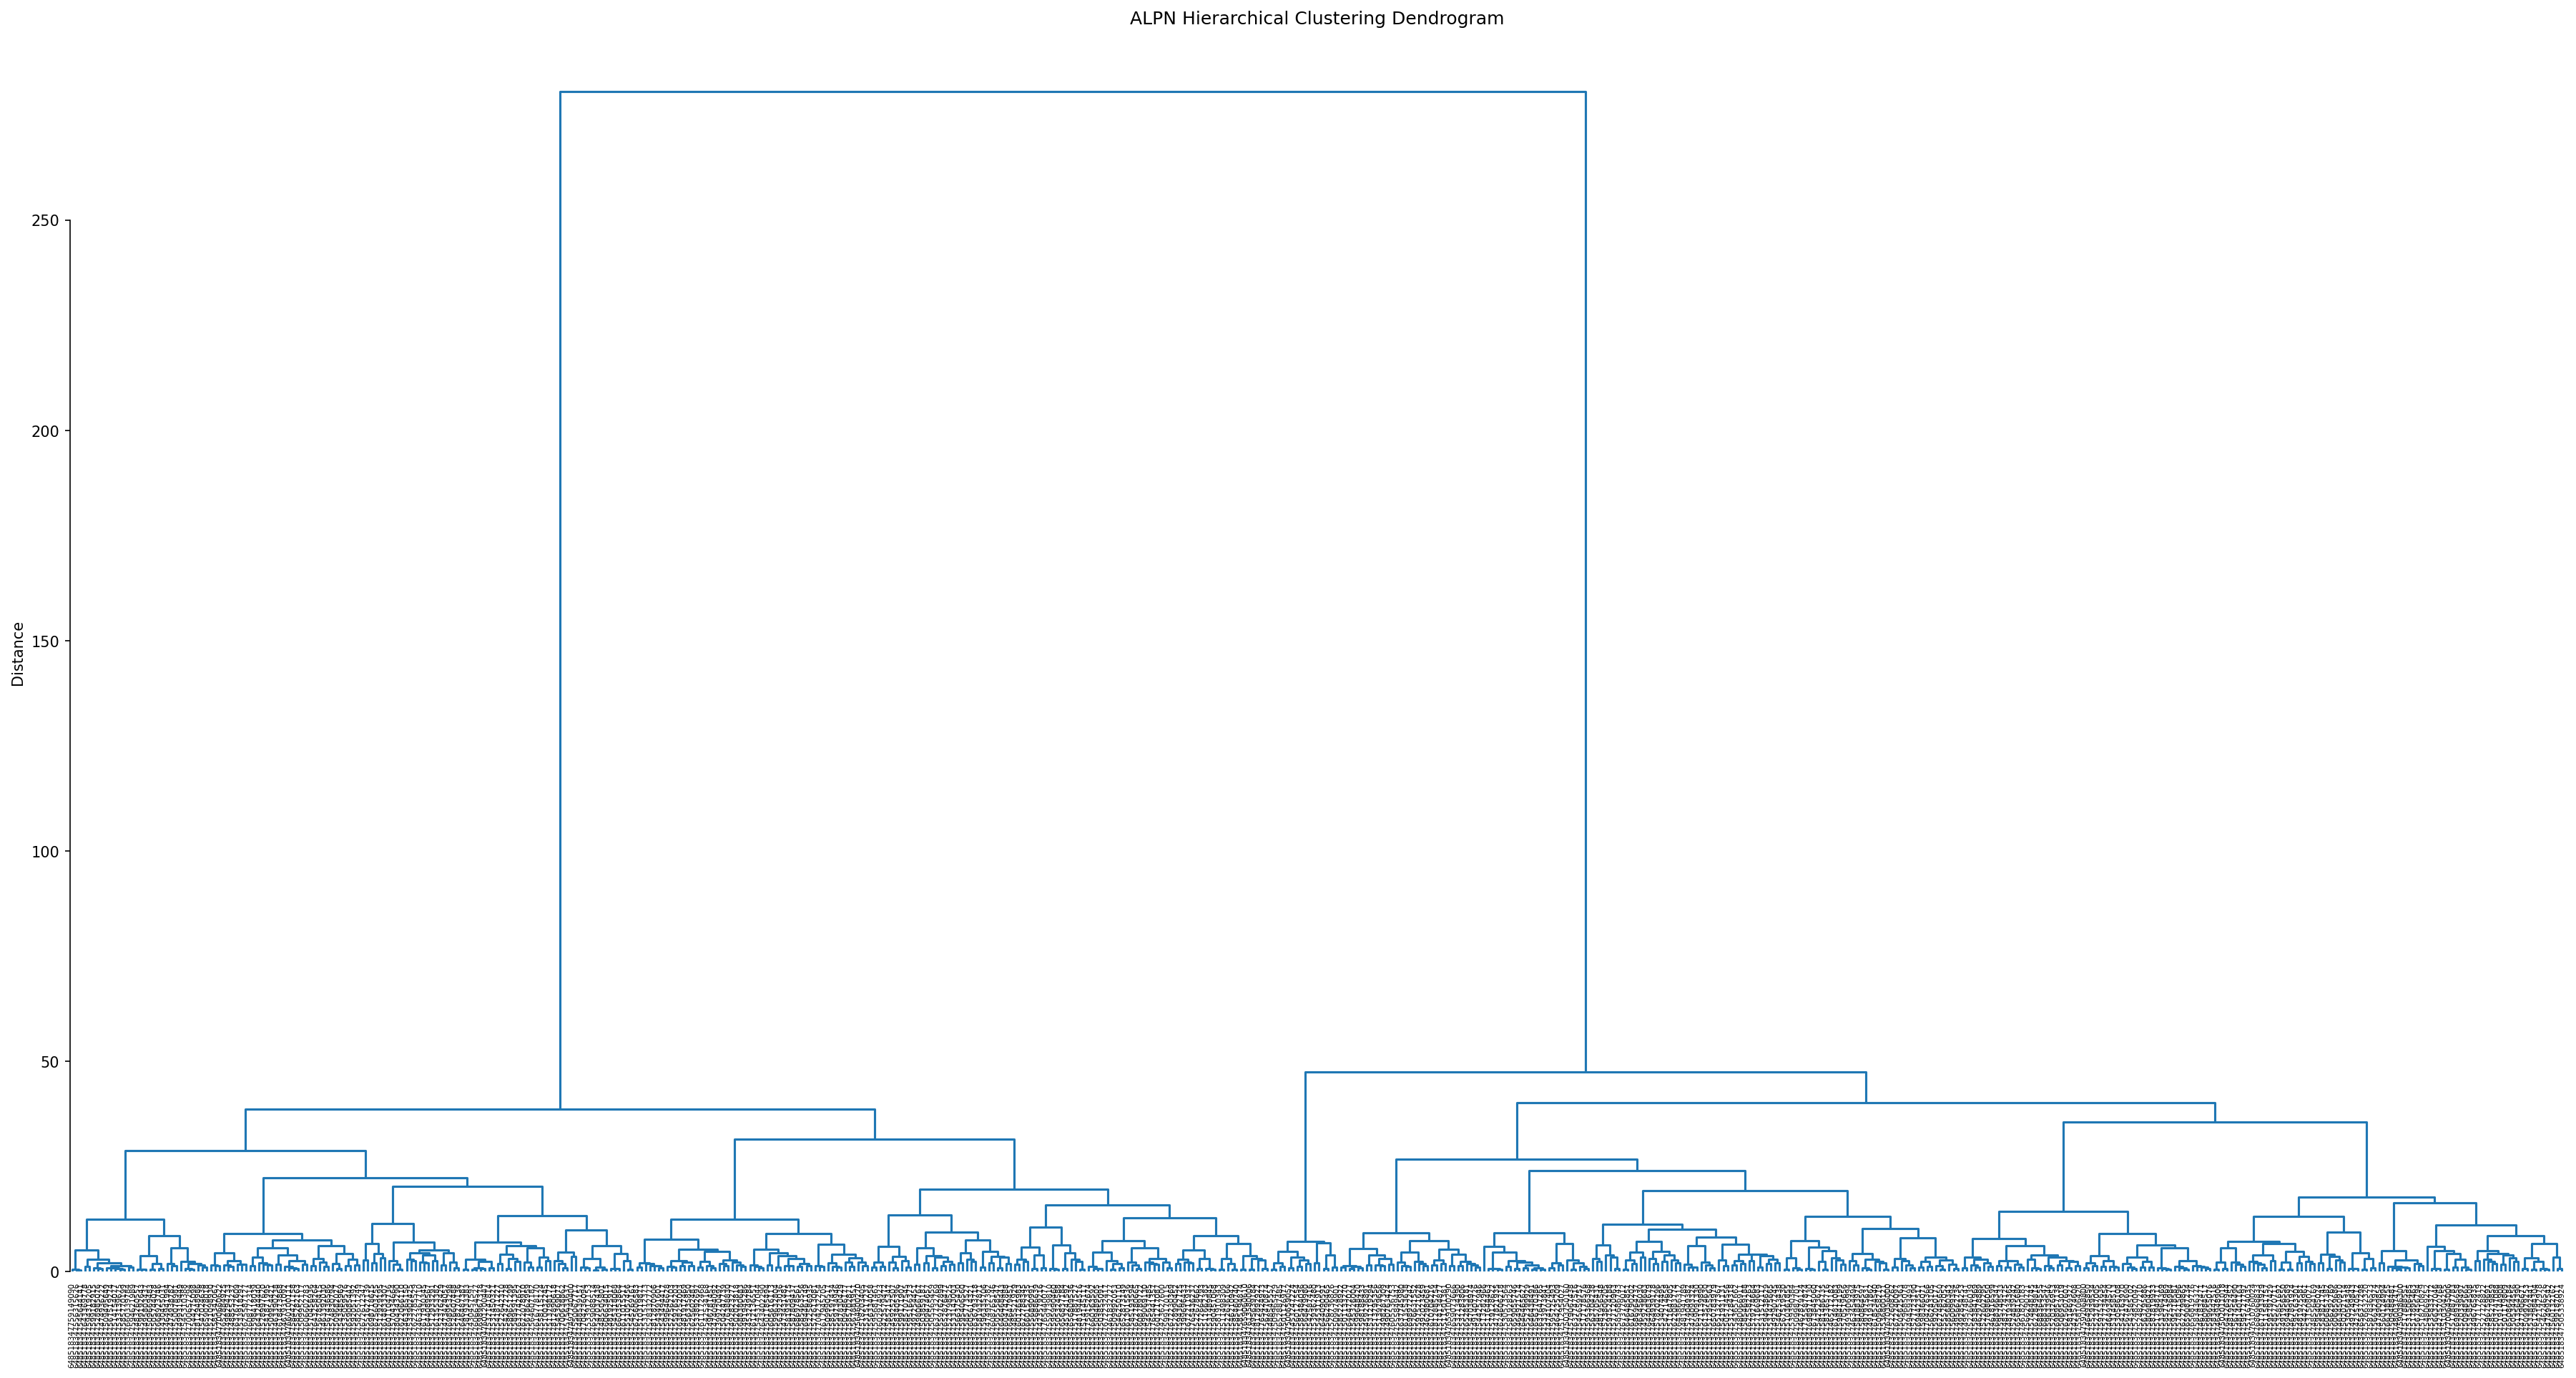

In [10]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
import matplotlib.colors as mcl
import seaborn as sns

set_link_color_palette([mcl.to_hex(c) for c in sns.color_palette("muted", 10)])

Z = linkage(aba, method="ward")

# Increase figure size and DPI for clarity
fig, ax = plt.subplots(figsize=(30, 15), dpi=150)

dn = dendrogram(
    Z, 
    labels=aba.columns,    # Set labels
    leaf_rotation=90,      # Rotate leaf labels vertically
    leaf_font_size=5,      # Make leaf labels smaller to fit better
    color_threshold=0,     # Disable color threshold or adjust as needed
    ax=ax
)

plt.title("ALPN Hierarchical Clustering Dendrogram")
ax.set(ylabel="Distance")

sns.despine(trim=True, bottom=True)
plt.show()
fig.savefig("ALPN_dendrogram.pdf")

# Mirroring neurons

Now that we have a general pipeline for clustering our neuron population, we can improve the predictions by mirroring the neurons on one side of the brain so that homologue neurons across hemispheres are clustered toogether. 

The first step to define our transformation is to load the template brain and the dotprops for the left and right side of the brain.

In [11]:
reference = pd.read_csv('ref.csv')

target = pd.read_csv('tar.csv')

alpnleft = alpn[alpn["side"] == "L"]
alpnright = alpn[alpn["side"] == "R"]

dpsl = flywire.get_l2_dotprops(alpnleft["root_id"])

dpsr = flywire.get_l2_dotprops(alpnright["root_id"])

dpsuml = dpsl * (1/1000)

dpsumr = dpsr * (1/1000)

aedestemplate = nv.transforms.templates.TemplateBrain(
    name="aedes",
    voxelsize=(0.512, 0.512, 0.512),
    boundingbox=[(35.296, 698.848),
                 (58.784, 522.144),
                 (0, 336.896)],
    units="um"
)

registered = nv.transforms.registry.register_templatebrain(aedestemplate)

Fetching L2 IDs:   0%|          | 0/295 [00:00<?, ?it/s]

Fetching L2 vectors:   0%|          | 0/176312 [00:00<?, ?it/s]

Creating dotprops:   0%|          | 0/295 [00:00<?, ?it/s]

Fetching L2 IDs:   0%|          | 0/277 [00:00<?, ?it/s]

Fetching L2 vectors:   0%|          | 0/169031 [00:00<?, ?it/s]

Creating dotprops:   0%|          | 0/277 [00:00<?, ?it/s]

Multiplying:   0%|          | 0/295 [00:00<?, ?it/s]

Multiplying:   0%|          | 0/277 [00:00<?, ?it/s]

Now we can move the subset of one side of neurons into symetric space to be mirrored.

In [13]:
symspacedpsumr = nv.xform(dpsumr, nv.transforms.thinplate.TPStransform(reference, target))


Xforming:   0%|          | 0/277 [00:00<?, ?it/s]

Then we can mirror the neurons and return them to the original space.

In [16]:
mirroredn = nv.mirror_brain(symspacedpsumr, template = "aedes")

Mirroring:   0%|          | 0/277 [00:00<?, ?it/s]

In [17]:
origspace = nv.xform(mirroredn, nv.transforms.thinplate.TPStransform(target, reference))

Xforming:   0%|          | 0/277 [00:00<?, ?it/s]

Now we can plot the mirrored neurons to see if our mirroring worked

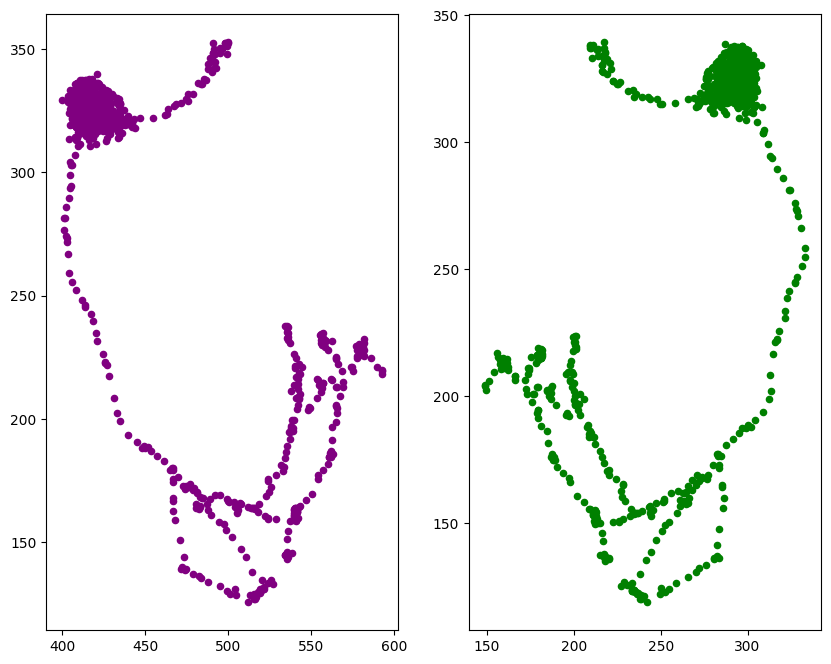

In [20]:
### just plot 1 to see, write more code to plot all in interactive plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
ax[0].scatter(dpsumr.points[0][:,0], dpsumr.points[0][:,1], c='purple', s=20)
ax[1].scatter(origspace.points[0][:,0], origspace.points[0][:,1],c='green', s=20)

plt.show()

# Clustering with mirror registration

Now we can re-run our clustering using the mirrored neurons plus the original set. 

In [ ]:
#dps_L_um.set_neuron_attributes([alpn_mirrored[x] for x in range(len(alpn_mirrored))], name='points') dont understand this line

In [21]:
all_dps = origspace + dpsuml #add left (now mirrored) and right

In [22]:
aba = nv.nblast_allbyall(all_dps, progress=True) #run all by all nblast 
aba

Preparing:   0%|          | 0/4 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

target,648518347570434664,648518347463367710,648518347512933291,648518347541871227,648518347510032245,648518347430457591,648518347698967378,648518347606634527,648518347812890618,648518347700638862,...,648518347531475665,648518347546253438,648518347585705431,648518347481956548,648518347673779012,648518347646485851,648518347459238683,648518347563795886,648518347563704238,648518347650783979
query,,,,,,,,,,,,,,,,,,,,,
648518347570434664,1.000000,-0.274006,0.034549,0.096150,0.236272,-0.034511,-0.060691,-0.034471,-0.208229,-0.134201,...,0.305212,0.203057,-0.035871,0.036591,-0.053613,-0.037395,-0.346680,-0.153848,-0.044356,0.354353
648518347463367710,-0.009942,1.000000,-0.091556,-0.446684,-0.067205,-0.154090,-0.150439,-0.155820,-0.150102,-0.060117,...,0.026808,0.041241,-0.026364,0.055152,-0.331596,-0.316235,-0.411202,-0.356968,-0.607751,-0.179701
648518347512933291,0.162454,-0.066633,1.000000,-0.209570,-0.033530,-0.089736,-0.044059,-0.096963,-0.074426,0.017645,...,0.364882,0.347723,0.099821,0.317485,0.149139,0.177708,-0.036369,-0.119248,-0.253430,-0.013202
648518347541871227,0.159696,-0.463650,-0.227295,1.000000,0.167980,-0.038730,-0.027045,0.009095,-0.370758,-0.383647,...,0.283701,0.190242,-0.367622,-0.142876,-0.332866,-0.328173,-0.486583,-0.111267,-0.136210,0.135202
648518347510032245,0.251211,-0.324595,-0.046583,0.005146,1.000000,0.179134,0.173969,0.183525,-0.115367,-0.071138,...,0.269274,-0.038886,-0.211167,-0.200051,-0.122587,-0.141499,-0.243854,-0.139434,-0.314450,0.086087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
648518347646485851,-0.129926,-0.234713,0.116489,-0.444235,-0.078215,-0.214474,-0.156677,-0.181506,0.072637,-0.144137,...,0.088576,0.085869,-0.045053,0.042364,0.733139,1.000000,-0.055555,-0.409207,-0.565812,-0.298366
648518347459238683,-0.300273,-0.389875,0.016442,-0.646759,-0.028415,-0.179318,-0.070646,-0.143225,0.221236,-0.044289,...,0.005925,0.268076,0.065172,-0.101736,0.531998,0.504856,1.000000,-0.344418,-0.574658,-0.480321
648518347563795886,-0.135958,-0.223514,-0.205748,0.038048,-0.049157,-0.135805,-0.133624,-0.108354,-0.171840,-0.229215,...,0.187981,0.195451,-0.443309,-0.209870,-0.462032,-0.487143,-0.462203,1.000000,-0.379203,-0.203748


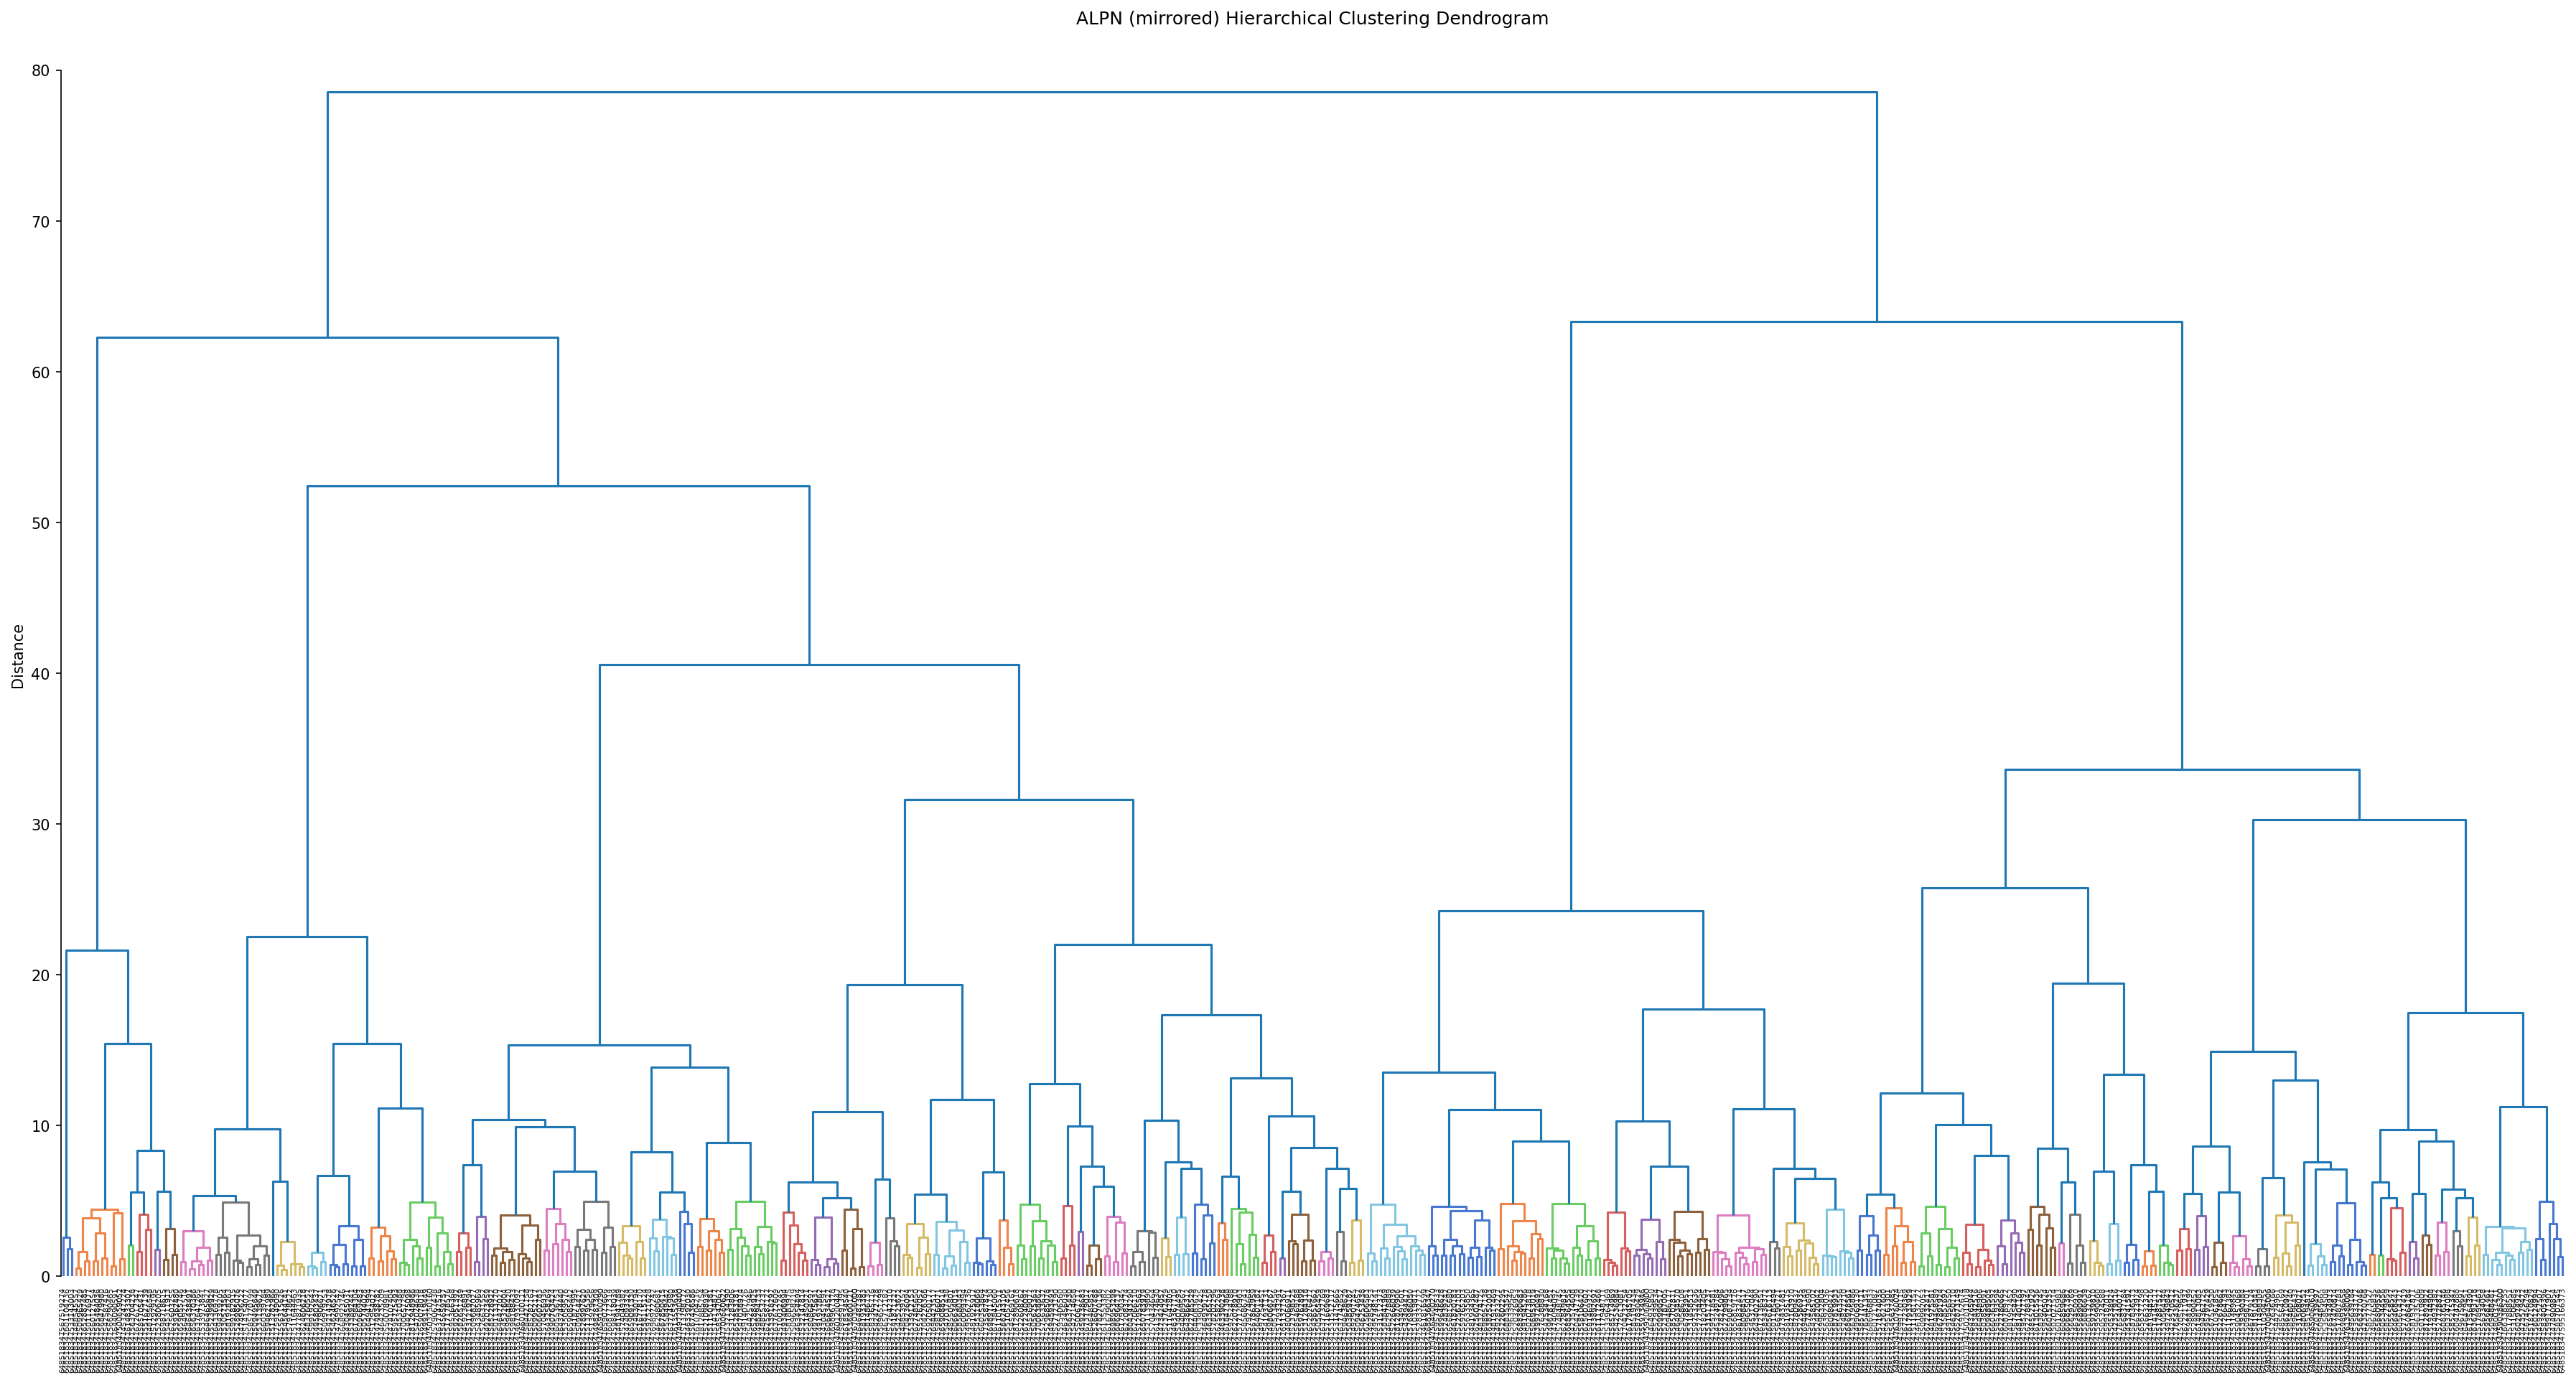

In [23]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
import matplotlib.colors as mcl
import seaborn as sns

set_link_color_palette([mcl.to_hex(c) for c in sns.color_palette("muted", 10)])


Z = linkage(aba, method="ward")

# Increase figure size and DPI for clarity
fig, ax = plt.subplots(figsize=(30, 15), dpi=150)

dn = dendrogram(
    Z, 
    labels=aba.columns,    # Set labels
    leaf_rotation=90,      # Rotate leaf labels vertically
    leaf_font_size=5,      # Make leaf labels smaller to fit better
    color_threshold=5,     # Disable color threshold or adjust as needed
    ax=ax
)

plt.title("ALPN (mirrored) Hierarchical Clustering Dendrogram")
ax.set(ylabel="Distance")

sns.despine(trim=True, bottom=True)
plt.show()
fig.savefig("ALPN_mirrored_dendrogram.pdf")